# **Part 2: Object Detection with YOLO**

**2.1 Basic Object Detection**

In [43]:
pip install ultralytics

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from deepface import DeepFace

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu


In [ ]:
model = YOLO('yolov8n.pt')


image 1/1 /content/Снимок экрана 2026-02-25 123043.png: 640x640 1 toilet, 439.7ms
Speed: 16.7ms preprocess, 439.7ms inference, 44.8ms postprocess per image at shape (1, 3, 640, 640)


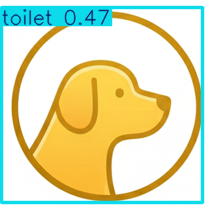

In [ ]:
results = model(r"/content/Снимок экрана 2026-02-25 123043.png")
results[0].show()

In [ ]:
for result in results:
    boxes = result.boxes
    for box in boxes:
        print(f"Class: {result.names[int(box.cls)]}, Confidence: {box.conf.item():.2f}")
        print(f"Bounding box (xyxy): {box.xyxy}")

Class: toilet, Confidence: 0.47
Bounding box (xyxy): tensor([[  1.7378,   7.9939, 202.6163, 202.2018]])


**2.2 Understanding YOLO Output**

**1.What is the confidence score?**

It is the probability that an object is present in the bounding box and that its class is predicted correctly. Usually, it ranges from 0 to 1.

**2.How are bounding box coordinates normalized?**

Coordinates are often normalized relative to the image size: from 0 to 1, where (0,0) is the top-left corner and (1,1) is the bottom-right corner.

**3.Difference between xyxy and xywh:**

xyxy → [x_min, y_min, x_max, y_max]

xywh → [x_center, y_center, width, height]

**2.3 Non-Max Suppression Experiments**

In [ ]:
results_conf_25 = model('/content/Снимок экрана 2026-02-25 123043.png', conf=0.25)
results_conf_50 = model('/content/Снимок экрана 2026-02-25 123043.png', conf=0.50)
results_conf_75 = model('/content/Снимок экрана 2026-02-25 123043.png', conf=0.75)


image 1/1 /content/Снимок экрана 2026-02-25 123043.png: 640x640 1 toilet, 222.1ms
Speed: 4.2ms preprocess, 222.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Снимок экрана 2026-02-25 123043.png: 640x640 (no detections), 230.3ms
Speed: 3.8ms preprocess, 230.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Снимок экрана 2026-02-25 123043.png: 640x640 (no detections), 225.7ms
Speed: 3.0ms preprocess, 225.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
results_iou_30 = model('/content/Снимок экрана 2026-02-25 123043.png', iou=0.3)
results_iou_50 = model('/content/Снимок экрана 2026-02-25 123043.png', iou=0.5)
results_iou_70 = model('/content/Снимок экрана 2026-02-25 123043.png', iou=0.7)


image 1/1 /content/Снимок экрана 2026-02-25 123043.png: 640x640 1 toilet, 244.7ms
Speed: 4.1ms preprocess, 244.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Снимок экрана 2026-02-25 123043.png: 640x640 1 toilet, 229.0ms
Speed: 3.1ms preprocess, 229.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Снимок экрана 2026-02-25 123043.png: 640x640 1 toilet, 239.9ms
Speed: 3.1ms preprocess, 239.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


**2.4 Video Object Detection (Optional Bonus)**

In [46]:
results = model('/content/video.mp4', save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/detect/predict


# **Part 3: Face Recognition with DeepFace**

**3.1 Face Verification**

In [ ]:
from deepface import DeepFace
result = DeepFace.verify(img1_path="/person_a_1.jpg", img2_path="/person_a_2.jpg")
print(result)

{'verified': False, 'distance': 0.964808, 'threshold': 0.68, 'confidence': 0.39, 'model': 'VGG-Face', 'detector_backend': 'opencv', 'similarity_metric': 'cosine', 'facial_areas': {'img1': {'x': 70, 'y': 37, 'w': 108, 'h': 108, 'left_eye': (140, 79), 'right_eye': (102, 80)}, 'img2': {'x': 93, 'y': 36, 'w': 103, 'h': 103, 'left_eye': (160, 75), 'right_eye': (125, 74)}}, 'time': 2.08}


**3.2 Face Analysis**

In [ ]:
analysis = DeepFace.analyze(img_path="/person_a_1.jpg", actions=['age', 'gender', 'emotion'])
print(analysis)

Action: age:   0%|          | 0/3 [00:00<?, ?it/s]    Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5


26-03-18 11:00:22 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...



  0%|          | 0.00/539M [00:00<?, ?B/s]
  7%|▋         | 37.7M/539M [00:00<00:01, 377MB/s]
 15%|█▍        | 79.2M/539M [00:00<00:01, 397MB/s]
 22%|██▏       | 119M/539M [00:00<00:01, 363MB/s] 
 29%|██▉       | 156M/539M [00:00<00:01, 365MB/s]
 36%|███▌      | 193M/539M [00:00<00:01, 334MB/s]
 43%|████▎     | 233M/539M [00:00<00:00, 353MB/s]
 50%|████▉     | 269M/539M [00:05<00:12, 21.5MB/s]
 59%|█████▊    | 316M/539M [00:05<00:06, 33.1MB/s]
 67%|██████▋   | 360M/539M [00:06<00:03, 47.6MB/s]
 73%|███████▎  | 396M/539M [00:06<00:02, 60.9MB/s]
 79%|███████▉  | 428M/539M [00:06<00:01, 66.1MB/s]
 84%|████████▍ | 452M/539M [00:06<00:01, 78.7MB/s]
 89%|████████▊ | 477M/539M [00:06<00:00, 93.8MB/s]
 93%|█████████▎| 503M/539M [00:06<00:00, 113MB/s] 
100%|██████████| 539M/539M [00:07<00:00, 75.7MB/s]
Action: gender:  33%|███▎      | 1/3 [00:14<00:29, 14.92s/it]Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/w

26-03-18 11:00:37 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...



  0%|          | 0.00/537M [00:00<?, ?B/s]
  8%|▊         | 42.5M/537M [00:00<00:01, 410MB/s]
 16%|█▌        | 87.0M/537M [00:00<00:01, 427MB/s]
 24%|██▍       | 130M/537M [00:00<00:01, 377MB/s] 
 31%|███▏      | 169M/537M [00:00<00:01, 224MB/s]
 39%|███▉      | 212M/537M [00:00<00:01, 272MB/s]
 46%|████▌     | 246M/537M [00:00<00:01, 274MB/s]
 52%|█████▏    | 278M/537M [00:01<00:02, 106MB/s]
 57%|█████▋    | 305M/537M [00:01<00:01, 125MB/s]
 61%|██████    | 329M/537M [00:01<00:01, 136MB/s]
 65%|██████▌   | 351M/537M [00:02<00:02, 67.7MB/s]
 68%|██████▊   | 368M/537M [00:02<00:02, 73.5MB/s]
 71%|███████▏  | 383M/537M [00:02<00:01, 82.3MB/s]
 74%|███████▍  | 397M/537M [00:03<00:01, 90.9MB/s]
 77%|███████▋  | 412M/537M [00:03<00:01, 99.5MB/s]
 80%|███████▉  | 427M/537M [00:03<00:01, 109MB/s] 
 82%|████████▏ | 443M/537M [00:03<00:00, 119MB/s]
 86%|████████▋ | 464M/537M [00:03<00:00, 140MB/s]
 90%|████████▉ | 481M/537M [00:03<00:00, 107MB/s]
 92%|█████████▏| 495M/537M [00:03<00:00, 113MB/

26-03-18 11:00:46 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...



100%|██████████| 5.98M/5.98M [00:00<00:00, 105MB/s]
Action: emotion: 100%|██████████| 3/3 [00:27<00:00,  9.13s/it]

[{'age': 24, 'region': {'x': 70, 'y': 37, 'w': 108, 'h': 108, 'left_eye': (140, 79), 'right_eye': (102, 80)}, 'face_confidence': 0.91, 'gender': {'Woman': np.float32(0.0033877343), 'Man': np.float32(99.99661)}, 'dominant_gender': 'Man', 'emotion': {'angry': np.float32(0.0574863), 'disgust': np.float32(2.503297e-08), 'fear': np.float32(0.015641082), 'happy': np.float32(0.00026406723), 'sad': np.float32(0.13617471), 'surprise': np.float32(0.0025249973), 'neutral': np.float32(99.78792)}, 'dominant_emotion': 'neutral'}]


**3.3 Face Embeddings**

In [50]:
embedding1 = DeepFace.represent(img_path="/person_a_1.jpg", model_name="Facenet")
embedding2 = DeepFace.represent(img_path="/person_a_2.jpg", model_name="Facenet")

In [51]:
distance = np.linalg.norm(np.array(embedding1[0]['embedding']) - np.array(embedding2[0]['embedding']))
print(distance)

17.43365923268486


# **Part 4: U-Net Architecture**

**4.2 Skip Connections Questions**

**1.What are skip connections in U-Net?**

They are direct connections between the encoder layers and the corresponding decoder layers.

**2.How do they help with information loss?**

Downsampling loses some spatial information. Skip connections pass this information directly to the decoder layer, improving detail recovery.

**3.What operation combines encoder and decoder features?**

Concatenation.
Summation is sometimes used, but the standard U-Net uses concatenation.

**4.3 U-Net Implementation**

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [ ]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.down(x)

In [ ]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

In [ ]:
double_conv = DoubleConv(3, 64)
test_input = torch.randn(1, 3, 256, 256)
output = double_conv(test_input)
print(f"Input shape: {test_input.shape}, Output shape: {output.shape}")

Input shape: torch.Size([1, 3, 256, 256]), Output shape: torch.Size([1, 64, 256, 256])
